# Estimation du prix au m²

**Objectif** : Construire un modèle baseline (OLS) **interprétable** pour estimer le **prix au m² (DH)** d'un bien immobilier à partir de ses caractéristiques :
- **Caractéristiques du bien** : type de bien, état, condition / zonage
- **Variables géomarketing (POI)** : proximité des écoles, banques, santé, commerces, transports, mer, parcs, nuisances, axes routiers
- **Variables socio-démographiques** : densité de population, taux d'activité, chômage, niveau d'études, taille de ménage

**Méthodologie suivie** :
1. Statistiques descriptives + tests de normalité
2. Analyse bivariée (ANOVA, corrélations Pearson)
3. Régression linéaire multiple (statsmodels)
4. Sélection de variables : Forward, Backward, Stepwise (AIC / BIC)
5. Détection de la multicolinéarité par VIF itératif
6. Diagnostic complet des hypothèses MCO (normalité, homoscédasticité, autocorrélation)
7. Validation hors-échantillon (Train / Test / K-fold)

## 1. Imports et configuration

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = 42

## 2. Chargement & nettoyage

In [2]:
import os 
os.chdir('C:\\Users\\del\\Desktop\\prix-immobilier-evaluation')

In [6]:
df = pd.read_csv("scrapping\\data\\data_finale.csv")
df.columns = df.columns.str.strip()

TARGET = "Prix Terrain au m² (DH)"
print(f"Shape initial : {df.shape}")
df.head()

Shape initial : (1477, 49)


,Préfecture,Arrondissement,Code Zone,Zone déchiffrée,Type de bien,État,Condition / Zonage,Prix Terrain au m² (DH),dist_education_min_m,dist_banque_min_m,...,nb_nuisance,Densite_pop_km2,Part_population_15_59_ans,Taille_de_ménage,Taux_activité,Taux_chômage,Part_salariés_parmi_actifs,Taux_analphabétisme,Part_population_niveau_études_supérieur,Taux_croissance
0,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Ancien,NaN,11000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
1,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Récent,NaN,14000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
2,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Neuf,NaN,16000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
3,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Terrain ZI,Loti,< à R+10,32000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
4,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Terrain ZI,Loti,>= à R+10,41000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1


In [3]:
# Valeurs manquantes
na = df.isnull().sum()
print("Variables avec NA :")
print(na[na > 0])

Variables avec NA :
Condition / Zonage    1176
dtype: int64


In [7]:
# Nettoyage
n0 = len(df)

# 1) On remplace les NAN de "Condition / Zonage" par "Aucune" (car il s'agit d'une variable dépendante au type de bien, et nan du au fait que Appartements n'ont pas de condition ou zonage)
df["Condition / Zonage"] = df["Condition / Zonage"].fillna("Aucune")
# 2) Suppression des prix aberrants (< 100 DH/m² = erreurs de saisie)
df = df[df[TARGET] >= 100].copy()
print(f"Observations supprimées : {n0 - len(df)}")
print(f"Échantillon final : {len(df)} observations")

Observations supprimées : 4
Échantillon final : 1473 observations


## 3. Statistiques descriptives

On regarde la cible : moyenne, médiane, écart-type, mais surtout **skewness** et **kurtosis**, qui nous diront si on doit transformer la variable.

In [8]:
y = df[TARGET]
desc = pd.Series({
    "n":            len(y),
    "moyenne":      y.mean(),
    "médiane":      y.median(),
    "écart-type":   y.std(),
    "CV (%)":       100 * y.std() / y.mean(),
    "min":          y.min(),
    "max":          y.max(),
    "skewness":     stats.skew(y),
    "kurtosis":     stats.kurtosis(y),
    "Q1":           y.quantile(.25),
    "Q3":           y.quantile(.75),
    "IQR":          y.quantile(.75) - y.quantile(.25),
})
desc.round(2)

n              1473.00
moyenne       13774.36
médiane       12000.00
écart-type     6970.98
CV (%)           50.61
min             808.00
max           65000.00
skewness          2.46
kurtosis          8.38
Q1            10000.00
Q3            15000.00
IQR            5000.00
dtype: float64

### 3.1 Tests de normalité

In [6]:
sw_stat, sw_p = stats.shapiro(y.sample(min(5000, len(y)), random_state=RNG))
jb_stat, jb_p = stats.jarque_bera(y)
ad_stat, ad_p = normal_ad(y)

pd.DataFrame({
    "Test":        ["Shapiro-Wilk", "Jarque-Bera", "Anderson-Darling"],
    "Statistique": [sw_stat, jb_stat, ad_stat],
    "p-value":     [sw_p, jb_p, ad_p],
    "H0 normalité":["rejetée"]*3
}).round(4)

,Test,Statistique,p-value,H0 normalité
0,Shapiro-Wilk,0.7717,0.0,rejetée
1,Jarque-Bera,5803.1772,0.0,rejetée
2,Anderson-Darling,89.2498,0.0,rejetée


**Conclusion** : la distribution du prix est asymétrique à droite (skew > 0) avec des queues lourdes (kurtosis > 3).
On applique une transformation logarithmique.

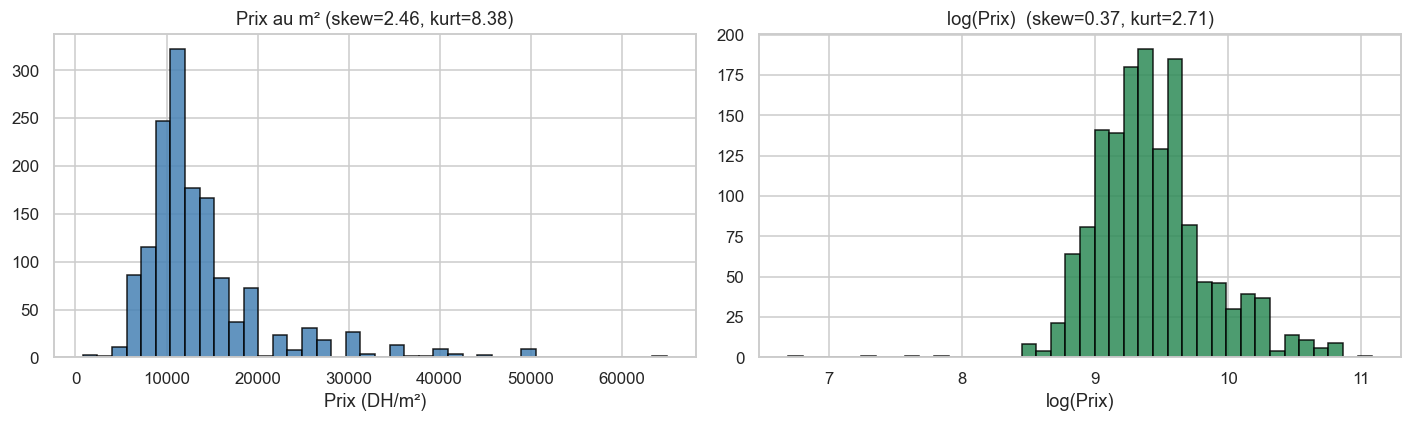

In [14]:
df["log_prix"] = np.log(y)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(y, bins=40, color="steelblue", edgecolor="black", alpha=.85)
ax[0].set_title(f"Prix au m² (skew={stats.skew(y):.2f}, kurt={stats.kurtosis(y):.2f})")
ax[0].set_xlabel("Prix (DH/m²)")

ax[1].hist(df["log_prix"], bins=40, color="seagreen", edgecolor="black", alpha=.85)
ax[1].set_title(f"log(Prix)  (skew={stats.skew(df['log_prix']):.2f}, kurt={stats.kurtosis(df['log_prix']):.2f})")
ax[1].set_xlabel("log(Prix)")
plt.tight_layout()
plt.show()

## 4. Analyse bivariée

### 4.1 ANOVA — Effet des variables catégorielles

In [9]:
rows = []
for cat in ["Type de bien", "État", "Condition / Zonage","Préfecture", "Arrondissement"]:
    groups = [g[TARGET].values for _, g in df.groupby(cat) if len(g) > 1]
    f_stat, f_p = stats.f_oneway(*groups)
    eta2 = (f_stat * (len(groups) - 1)) / (f_stat * (len(groups) - 1) + (len(df) - len(groups)))
    rows.append([cat, f_stat, f_p, eta2])
pd.DataFrame(rows, columns=["Variable", "F", "p-value", "η²"]).round(4)

,Variable,F,p-value,η²
0,Type de bien,119.4187,0.0,0.2893
1,État,145.5782,0.0,0.2292
2,Condition / Zonage,31.7822,0.0,0.2465
3,Préfecture,70.5241,0.0,0.2520
4,Arrondissement,35.8320,0.0,0.2695


### 4.2 Corrélations

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in [TARGET, "log_prix"]]

corr_p = df[num_cols + [TARGET]].corr(method="pearson")[TARGET].drop(TARGET)
corr_s = df[num_cols + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)

corr_table = pd.DataFrame({"Pearson": corr_p, "Spearman": corr_s})
corr_table["|Pearson|"] = corr_table["Pearson"].abs()
corr_table = corr_table.sort_values("|Pearson|", ascending=False)
corr_table.head(15).round(3)

,Pearson,Spearman,|Pearson|
Taille_de_ménage,-0.468,-0.481,0.468
temps_Maarif,-0.436,-0.515,0.436
nb_commerces_1km,0.416,0.391,0.416
temps_port,-0.408,-0.416,0.408
Part_population_niveau_études_supérieur,0.370,0.391,0.370
nb_banques_1km,0.359,0.353,0.359
nb_sante_1km,0.355,0.322,0.355
nb_restaurants_500m,0.348,0.399,0.348
Taux_analphabétisme,-0.341,-0.404,0.341
nb_axes_500m,0.332,0.330,0.332


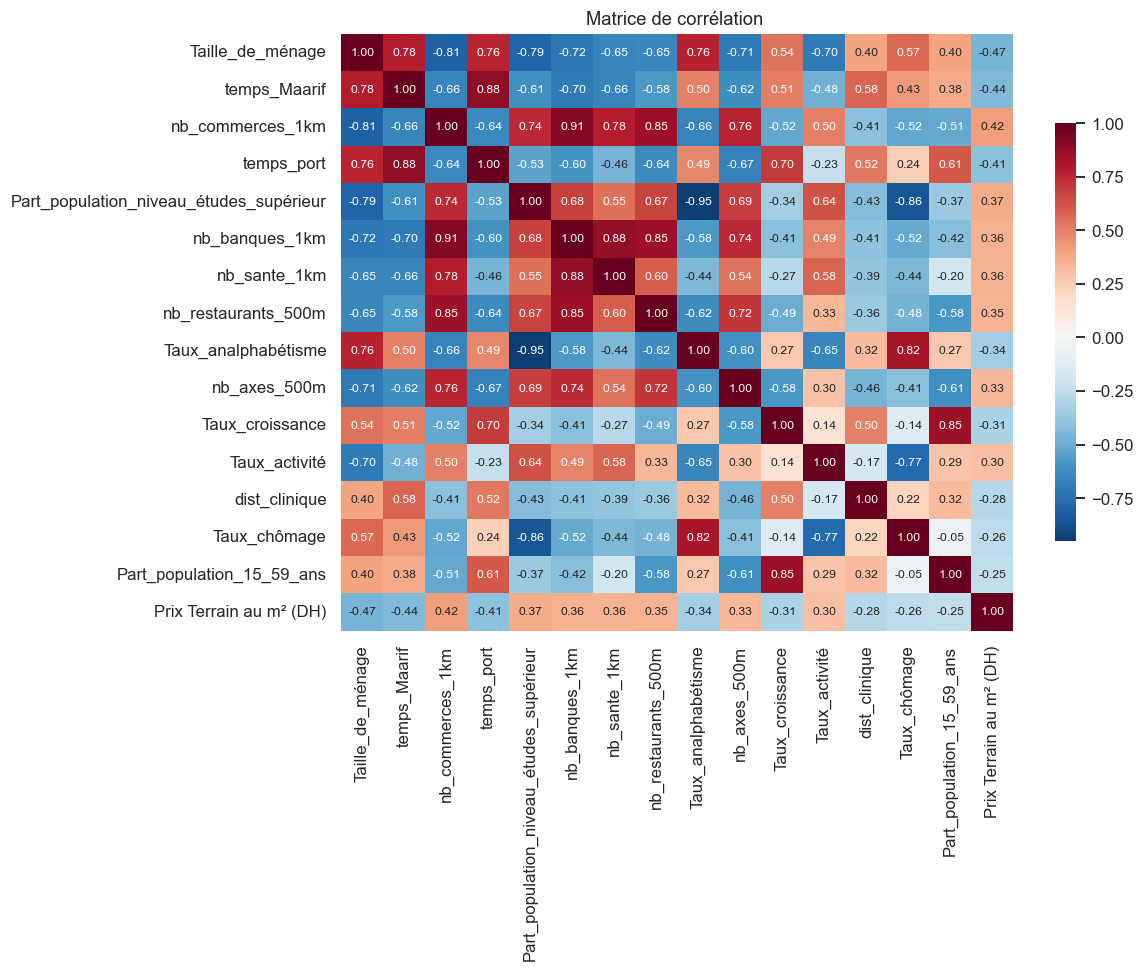

In [12]:
# Heatmap des  variables les plus corrélées au prix
fig, ax = plt.subplots(figsize=(11, 9))
top_vars = corr_table.head(15).index.tolist() + [TARGET]
sns.heatmap(df[top_vars].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, annot_kws={"size":8}, cbar_kws={"shrink":.7})
ax.set_title("Matrice de corrélation ")
plt.tight_layout()
plt.show()

## 5. Préparation pour la modélisation

- Encodage one-hot des variables catégorielles (Type de bien, État, Préfecture)
- On retire `Code Zone`, `Zone déchiffrée`, `Arrondissement` (redondance avec Préfecture)
- Imputation médiane pour les NA résiduels

In [15]:
cat_features = ["Type de bien", "État", "Préfecture", "Condition / Zonage"]
drop_cols    = ["Code Zone", "Zone déchiffrée", "Arrondissement"]

X = df.drop(columns=[TARGET, "log_prix"] + drop_cols)
X = pd.get_dummies(X, columns=cat_features, drop_first=True)
X = X.astype(float).fillna(X.median(numeric_only=True))

y_log = df["log_prix"]

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.20, random_state=RNG)
print(f"Train : {X_train.shape}    Test : {X_test.shape}")
print(f"Nombre total de prédicteurs : {X.shape[1]}")

Train : (1178, 85)    Test : (295, 85)
Nombre total de prédicteurs : 85


## 6.  Détection de la multicolinéarité par VIF itératif

**Variance Inflation Factor** : pour chaque variable Xⱼ on calcule
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
où $R_j^2$ est le R² de la régression de Xⱼ sur toutes les autres explicatives.

Règles de décision usuelles :
- VIF ≤ 5  → OK
- VIF > 10 → multicolinéarité problématique

On retire **itérativement** la variable avec le VIF le plus élevé jusqu'à ce que tous soient ≤ 5.

In [20]:
def compute_vif(X_df):
    vif = pd.DataFrame({
        "variable": X_df.columns,
        "VIF": [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    })
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

# VIF initial
vif_initial = compute_vif(X_train)
print(f"Variables avec VIF infini : {(vif_initial['VIF'] == np.inf).sum()}")
print(f"Variables avec VIF > 5   : {(vif_initial['VIF'] > 5).sum()}")
vif_initial.head(15)

Variables avec VIF infini : 7
Variables avec VIF > 5   : 58


,variable,VIF
0,dist_education_min_m,inf
1,dist_boulevard_principal,inf
2,dist_voie_primaire_min_m,inf
3,dist_ecole,inf
4,Type de bien_Terrain ZI,inf
5,Type de bien_Terrain ZV,inf
6,État_Loti,inf
7,Part_population_15_59_ans,2.290203e+07
8,Taux_activité,1.853143e+07
9,densite_education,1.238155e+07


In [43]:
def vif_filter(X_df, threshold=5.0, verbose=True):
    """Retire itérativement la variable au VIF le plus haut tant que VIF > threshold."""
    X_curr = X_df.copy()
    removed = []
    iter_log = []
    while True:
        vif = compute_vif(X_curr)
        max_vif = vif["VIF"].iloc[0]
        if max_vif <= threshold or len(X_curr.columns) <= 1:
            break
        var_out = vif["variable"].iloc[0]
        removed.append((var_out, max_vif))
        iter_log.append({"iter": len(removed),
                         "variable_retirée": var_out,
                         "VIF": max_vif,
                         "nb_var_restantes": len(X_curr.columns) - 1})
        X_curr = X_curr.drop(columns=[var_out])
        if verbose and len(removed) <= 8:
            print(f"  Itér {len(removed):2d} : retire '{var_out[:35]:35s}' (VIF = {max_vif:.1f})")
    return X_curr, pd.DataFrame(iter_log), removed

print("Filtrage VIF itératif (seuil = 5) :")
X_train_vif, vif_history, vif_removed = vif_filter(X_train, threshold=5.0)    
print(f"\nVariables initiales : {X_train.shape[1]}")
print(f"Variables retenues  : {X_train_vif.shape[1]}")
print(f"Variables retirées  : {len(vif_removed)}")

Filtrage VIF itératif (seuil = 5) :
  Itér  1 : retire 'dist_education_min_m               ' (VIF = inf)
  Itér  2 : retire 'dist_boulevard_principal           ' (VIF = inf)
  Itér  3 : retire 'État_Loti                          ' (VIF = inf)
  Itér  4 : retire 'Part_population_15_59_ans          ' (VIF = 22902029.7)
  Itér  5 : retire 'densite_education                  ' (VIF = 55977077.7)
  Itér  6 : retire 'temps_SidiMaarouf                  ' (VIF = 36685.5)
  Itér  7 : retire 'Taux_activité                      ' (VIF = 26970.8)
  Itér  8 : retire 'Taille_de_ménage                   ' (VIF = 26238.5)

Variables initiales : 85
Variables retenues  : 48
Variables retirées  : 37


In [44]:
print("Variables conservées après filtrage VIF :")
print(list(X_train_vif.columns))
print()
print("VIF final :")
compute_vif(X_train_vif).round(2)

Variables conservées après filtrage VIF :
['nb_nuisance_500m', 'dist_voie_primaire_min_m', 'dist_voie_secondaire_min_m', 'nb_stations_1km', 'nb_restaurants_500m', 'dist_mer', 'surface_verte_1km', 'Taux_croissance', 'Type de bien_Appartement sécurisé', 'Type de bien_Maison', 'Type de bien_Terrain ZV', 'Type de bien_Villa', 'État_Neuf', 'État_Récent', 'Préfecture_Ain Sebaâ Hay Mohammadi', "Préfecture_Ben M'Sick", 'Préfecture_Derb Sultan-Al Fida', 'Préfecture_Hay Hassani', 'Préfecture_Mly Rachid', 'Préfecture_Sidi Bernoussi', 'Condition / Zonage_< à R+5', 'Condition / Zonage_<= 1000 m2', 'Condition / Zonage_<= R+5', 'Condition / Zonage_<= à R+2', 'Condition / Zonage_<= à R+3', 'Condition / Zonage_<= à R+4', 'Condition / Zonage_<= à R+5', 'Condition / Zonage_> 1000 m2', 'Condition / Zonage_> à R+2', 'Condition / Zonage_> à R+3', 'Condition / Zonage_> à R+4', 'Condition / Zonage_> à R+5', 'Condition / Zonage_>= à R+10', 'Condition / Zonage_>= à R+5', 'Condition / Zonage_CC-MA10             

,variable,VIF
0,dist_mer,4.85
1,nb_stations_1km,4.51
2,nb_restaurants_500m,4.40
3,Taux_croissance,4.34
4,surface_verte_1km,4.26
5,dist_voie_primaire_min_m,4.13
6,nb_nuisance_500m,3.98
7,Préfecture_Hay Hassani,3.55
8,dist_voie_secondaire_min_m,2.78
9,Préfecture_Ain Sebaâ Hay Mohammadi,2.77


## 7. Modèle OLS 


In [23]:
# OLS après filtrage VIF
X_train_vif_sm = sm.add_constant(X_train_vif)
ols_vif = sm.OLS(y_train, X_train_vif_sm).fit()

print(f"Modèle après VIF :")
print(f"  R²     = {ols_vif.rsquared:.4f}    (vs full : {ols_full.rsquared:.4f})")
print(f"  R² adj = {ols_vif.rsquared_adj:.4f}    (vs full : {ols_full.rsquared_adj:.4f})")
print(f"  AIC    = {ols_vif.aic:.1f}      (vs full : {ols_full.aic:.1f})")
print(f"  BIC    = {ols_vif.bic:.1f}      (vs full : {ols_full.bic:.1f})")

Modèle après VIF :
  R²     = 0.5932    (vs full : 0.7635)
  R² adj = 0.5763    (vs full : 0.7462)
  AIC    = 344.7      (vs full : -228.1)
  BIC    = 588.1      (vs full : 182.7)


## 8.  Sélection de variables : Forward, Backward, Stepwise

On part du jeu **après filtrage VIF** et on applique trois algorithmes classiques de sélection guidés par l'**AIC** (par défaut) ou le **BIC**.

> **AIC** = $2k - 2\ln(L)$ — pénalise modérément la complexité
> **BIC** = $k\ln(n) - 2\ln(L)$ — pénalise plus fortement (meilleur pour la parcimonie)

In [24]:
def fit_ols(X_df, y_s):
    return sm.OLS(y_s, sm.add_constant(X_df)).fit()

def forward_selection(X_df, y_s, criterion="aic", verbose=True):
    """Sélection ascendante : on ajoute la variable qui réduit le plus l'AIC/BIC."""
    remaining = list(X_df.columns)
    selected  = []
    current_score = np.inf
    history = []
    step = 0
    while remaining:
        scores = []
        for var in remaining:
            cols = selected + [var]
            sc = getattr(fit_ols(X_df[cols], y_s), criterion)
            scores.append((sc, var))
        scores.sort()
        best_score, best_var = scores[0]
        if best_score < current_score:
            step += 1
            history.append({"step":step, "action":"+","variable":best_var,
                            criterion.upper():best_score})
            if verbose and step <= 8:
                print(f"  + {best_var[:40]:40s}  ({criterion.upper()} = {best_score:.2f})")
            current_score = best_score
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break
    return selected, pd.DataFrame(history)

print("=== FORWARD SELECTION (AIC) ===")
fwd_vars, fwd_hist = forward_selection(X_train_vif, y_train, criterion="aic")
print(f"\n→ {len(fwd_vars)} variables retenues")

=== FORWARD SELECTION (AIC) ===
  + nb_restaurants_500m                       (AIC = 1156.43)
  + Condition / Zonage_> à R+5                (AIC = 1094.71)
  + Condition / Zonage_PT : 10 000/¨PC        (AIC = 1050.09)
  + Condition / Zonage_> à R+3                (AIC = 1008.96)
  + Préfecture_Sidi Bernoussi                 (AIC = 962.64)
  + Préfecture_Ain Sebaâ Hay Mohammadi        (AIC = 911.15)
  + Préfecture_Mly Rachid                     (AIC = 851.84)
  + Type de bien_Villa                        (AIC = 790.33)

→ 32 variables retenues


In [25]:
def backward_selection(X_df, y_s, criterion="aic", verbose=True):
    """Sélection descendante : on retire la variable dont la suppression réduit le plus l'AIC/BIC."""
    selected = list(X_df.columns)
    current_score = getattr(fit_ols(X_df[selected], y_s), criterion)
    history = [{"step":0, "action":"start", "variable":"(toutes)",
                criterion.upper(): current_score}]
    step = 0
    while len(selected) > 1:
        scores = []
        for var in selected:
            cols = [v for v in selected if v != var]
            sc = getattr(fit_ols(X_df[cols], y_s), criterion)
            scores.append((sc, var))
        scores.sort()
        best_score, best_var = scores[0]
        if best_score < current_score:
            step += 1
            history.append({"step":step, "action":"-","variable":best_var,
                            criterion.upper():best_score})
            if verbose and step <= 8:
                print(f"  - {best_var[:40]:40s}  ({criterion.upper()} = {best_score:.2f})")
            current_score = best_score
            selected.remove(best_var)
        else:
            break
    return selected, pd.DataFrame(history)

print("=== BACKWARD SELECTION (AIC) ===")
bwd_vars, bwd_hist = backward_selection(X_train_vif, y_train, criterion="aic")
print(f"\n→ {len(bwd_vars)} variables retenues")

=== BACKWARD SELECTION (AIC) ===
  - Condition / Zonage_<= à R+2               (AIC = 342.67)
  - nb_nuisance_500m                          (AIC = 340.68)
  - Condition / Zonage_Si ST < 600 m2         (AIC = 338.71)
  - Condition / Zonage_Totaux                 (AIC = 336.77)
  - Condition / Zonage_Si ST >= 1000 m2       (AIC = 334.93)
  - Condition / Zonage_Si ST < 1000 m2        (AIC = 333.12)
  - Condition / Zonage_<= R+5                 (AIC = 331.67)
  - surface_verte_1km                         (AIC = 330.34)

→ 32 variables retenues


In [26]:
def stepwise_selection(X_df, y_s, criterion="aic", verbose=True):
    """Sélection mixte (ajout + suppression alternés)."""
    remaining = list(X_df.columns)
    selected  = []
    current_score = np.inf
    history = []
    step = 0
    while True:
        changed = False
        # 1) tentative d'ajout
        if remaining:
            scores = [(getattr(fit_ols(X_df[selected + [v]], y_s), criterion), v) for v in remaining]
            scores.sort()
            best_score, best_var = scores[0]
            if best_score < current_score:
                step += 1
                history.append({"step":step,"action":"+","variable":best_var,
                                criterion.upper():best_score})
                if verbose and step <= 12:
                    print(f"  + {best_var[:40]:40s}  ({criterion.upper()} = {best_score:.2f})")
                current_score = best_score
                selected.append(best_var)
                remaining.remove(best_var)
                changed = True
        # 2) tentative de retrait
        if len(selected) > 1:
            scores = [(getattr(fit_ols(X_df[[v for v in selected if v != var]], y_s), criterion), var)
                      for var in selected]
            scores.sort()
            best_score, best_var = scores[0]
            if best_score < current_score:
                step += 1
                history.append({"step":step,"action":"-","variable":best_var,
                                criterion.upper():best_score})
                if verbose and step <= 12:
                    print(f"  - {best_var[:40]:40s}  ({criterion.upper()} = {best_score:.2f})")
                current_score = best_score
                selected.remove(best_var)
                remaining.append(best_var)
                changed = True
        if not changed:
            break
    return selected, pd.DataFrame(history)

print("=== STEPWISE SELECTION (AIC) ===")
step_vars, step_hist = stepwise_selection(X_train_vif, y_train, criterion="aic")
print(f"\n→ {len(step_vars)} variables retenues")

=== STEPWISE SELECTION (AIC) ===
  + nb_restaurants_500m                       (AIC = 1156.43)
  + Condition / Zonage_> à R+5                (AIC = 1094.71)
  + Condition / Zonage_PT : 10 000/¨PC        (AIC = 1050.09)
  + Condition / Zonage_> à R+3                (AIC = 1008.96)
  + Préfecture_Sidi Bernoussi                 (AIC = 962.64)
  + Préfecture_Ain Sebaâ Hay Mohammadi        (AIC = 911.15)
  + Préfecture_Mly Rachid                     (AIC = 851.84)
  + Type de bien_Villa                        (AIC = 790.33)
  + dist_voie_primaire_min_m                  (AIC = 737.02)
  + Condition / Zonage_<= à R+5               (AIC = 683.12)
  + Condition / Zonage_>= à R+5               (AIC = 640.93)
  + Type de bien_Maison                       (AIC = 606.40)

→ 32 variables retenues


### 8.1 Sélection avec critère BIC (plus parcimonieux)

In [27]:
print("=== STEPWISE SELECTION (BIC) ===")
step_vars_bic, step_hist_bic = stepwise_selection(X_train_vif, y_train,
                                                   criterion="bic", verbose=False)
print(f"→ {len(step_vars_bic)} variables retenues (BIC, plus strict)")
print("\nVariables retenues (BIC) :")
for v in step_vars_bic:
    print(f"  • {v}")

=== STEPWISE SELECTION (BIC) ===
→ 21 variables retenues (BIC, plus strict)

Variables retenues (BIC) :
  • Condition / Zonage_> à R+5
  • Condition / Zonage_PT : 10 000/¨PC
  • Condition / Zonage_> à R+3
  • Préfecture_Sidi Bernoussi
  • Préfecture_Ain Sebaâ Hay Mohammadi
  • Préfecture_Mly Rachid
  • Type de bien_Villa
  • Condition / Zonage_<= à R+5
  • Condition / Zonage_>= à R+5
  • Type de bien_Maison
  • Condition / Zonage_< à R+5
  • dist_mer
  • Préfecture_Hay Hassani
  • Condition / Zonage_<= à R+3
  • Préfecture_Ben M'Sick
  • Condition / Zonage_>= à R+10
  • Préfecture_Derb Sultan-Al Fida
  • État_Récent
  • Type de bien_Terrain ZV
  • Condition / Zonage_<= 1000 m2
  • Condition / Zonage_CC-MA10                                     PT : 12 000/PC


## 9. Comparaison des sous-modèles

In [31]:
def evaluate(X_train_sub, X_test_sub, y_train, y_test, label):
    Xtr = sm.add_constant(X_train_sub)
    Xte = sm.add_constant(X_test_sub)
    m = sm.OLS(y_train, Xtr).fit()
    y_pred_tr = m.predict(Xtr)
    y_pred_te = m.predict(Xte)
    return {
        "Modèle":   label,
        "k":        X_train_sub.shape[1],
        "R²_train": m.rsquared,
        "R²_adj":   m.rsquared_adj,
        "AIC":      m.aic,
        "BIC":      m.bic,
        "RMSE_test (DH)": np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_te))),
        "MAPE_test (%)":  np.mean(np.abs((np.exp(y_test) - np.exp(y_pred_te)) / np.exp(y_test))) * 100,
        "R²_test":  r2_score(np.exp(y_test), np.exp(y_pred_te))
    }

results = [
    evaluate(X_train_vif,            X_test[X_train_vif.columns], y_train, y_test, "OLS simple"),
    evaluate(X_train_vif[fwd_vars],  X_test[fwd_vars],  y_train, y_test, "Forward (AIC)"),
    evaluate(X_train_vif[bwd_vars],  X_test[bwd_vars],  y_train, y_test, "Backward (AIC)"),
    evaluate(X_train_vif[step_vars], X_test[step_vars], y_train, y_test, "Stepwise (AIC)"),
    evaluate(X_train_vif[step_vars_bic], X_test[step_vars_bic], y_train, y_test, "Stepwise (BIC)"),
]
res_df = pd.DataFrame(results).round(4)
res_df

,Modèle,k,R²_train,R²_adj,AIC,BIC,RMSE_test (DH),MAPE_test (%),R²_test
0,OLS simple,48,0.5932,0.5763,344.6667,588.1023,4883.0230,18.1746,0.4374
1,Forward (AIC),32,0.5895,0.5780,325.4879,492.8498,4918.7346,18.3911,0.4292
2,Backward (AIC),32,0.5895,0.5780,325.4879,492.8498,4918.7346,18.3911,0.4292
3,Stepwise (AIC),32,0.5895,0.5780,325.4879,492.8498,4918.7346,18.3911,0.4292
4,Stepwise (BIC),21,0.5721,0.5643,352.4342,464.0088,5047.7405,19.0076,0.3988


## 9. Modèle final retenu (OLS)


In [47]:
# On choisit le OLS simple  comme modèle final
final_vars = ['nb_nuisance_500m', 'dist_voie_primaire_min_m', 'dist_voie_secondaire_min_m', 'nb_stations_1km', 'nb_restaurants_500m', 'dist_mer', 'surface_verte_1km', 'Taux_croissance', 'Type de bien_Appartement sécurisé', 'Type de bien_Maison', 'Type de bien_Terrain ZV', 'Type de bien_Villa', 'État_Neuf', 'État_Récent', 'Préfecture_Ain Sebaâ Hay Mohammadi', "Préfecture_Ben M'Sick", 'Préfecture_Derb Sultan-Al Fida', 'Préfecture_Hay Hassani', 'Préfecture_Mly Rachid', 'Préfecture_Sidi Bernoussi', 'Condition / Zonage_< à R+5', 'Condition / Zonage_<= 1000 m2', 'Condition / Zonage_<= R+5', 'Condition / Zonage_<= à R+2', 'Condition / Zonage_<= à R+3', 'Condition / Zonage_<= à R+4', 'Condition / Zonage_<= à R+5', 'Condition / Zonage_> 1000 m2', 'Condition / Zonage_> à R+2', 'Condition / Zonage_> à R+3', 'Condition / Zonage_> à R+4', 'Condition / Zonage_> à R+5', 'Condition / Zonage_>= à R+10', 'Condition / Zonage_>= à R+5', 'Condition / Zonage_CC-MA10                                     PT : 12 000/PC', 'Condition / Zonage_CS-AC13                                     PT : 12 000/PC', 'Condition / Zonage_CS-AC15                                         PT : 12 000/PC', 'Condition / Zonage_CS-HH18                                    PT : 10 000/PC', 'Condition / Zonage_CS-HH3                                                                                PT : 16 000/PC', 'Condition / Zonage_PT : 10 000/¨PC', 'Condition / Zonage_R+5', 'Condition / Zonage_Si ST < 1000 m2', 'Condition / Zonage_Si ST < 600 m2', 'Condition / Zonage_Si ST <= 200 m2', 'Condition / Zonage_Si ST > 200 m2', 'Condition / Zonage_Si ST >= 1000 m2', 'Condition / Zonage_Si ST >= 600 m2', 'Condition / Zonage_Totaux']

X_train_final_sm = sm.add_constant(X_train_vif)
X_test_final_sm  = sm.add_constant(X_test[final_vars])

ols_final = sm.OLS(y_train, X_train_final_sm).fit()
print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:               log_prix   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     35.06
Date:                Fri, 08 May 2026   Prob (F-statistic):          3.79e-186
Time:                        11:32:10   Log-Likelihood:                -124.33
No. Observations:                1178   AIC:                             344.7
Df Residuals:                    1130   BIC:                             588.1
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                                                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [35]:
# Coefficients ordonnés par p-value
coef_final = pd.DataFrame({
    "coef":      ols_final.params,
    "std_err":   ols_final.bse,
    "t":         ols_final.tvalues,
    "p_value":   ols_final.pvalues,
    "ic_low":    ols_final.conf_int()[0],
    "ic_high":   ols_final.conf_int()[1],
}).round(4).sort_values("p_value")
# Coefficients statistiquement significatifs au seuil de 5%
coef_final[coef_final["p_value"] < 0.05]

,coef,std_err,t,p_value,ic_low,ic_high
const,9.7662,0.0668,146.1272,0.0000,9.6351,9.8973
dist_mer,-0.0000,0.0000,-5.7980,0.0000,-0.0001,-0.0000
Type de bien_Villa,-0.1176,0.0261,-4.5024,0.0000,-0.1689,-0.0664
Type de bien_Maison,0.2389,0.0232,10.2968,0.0000,0.1934,0.2844
Préfecture_Ain Sebaâ Hay Mohammadi,-0.4406,0.0363,-12.1268,0.0000,-0.5118,-0.3693
Préfecture_Mly Rachid,-0.6535,0.0667,-9.7912,0.0000,-0.7845,-0.5226
Préfecture_Hay Hassani,-0.3418,0.0674,-5.0724,0.0000,-0.4740,-0.2096
Préfecture_Ben M'Sick,-0.3367,0.0563,-5.9823,0.0000,-0.4471,-0.2263
Condition / Zonage_<= à R+3,0.2535,0.0386,6.5616,0.0000,0.1777,0.3293
Condition / Zonage_<= à R+5,0.5227,0.0606,8.6275,0.0000,0.4038,0.6416


## 10. Diagnostic des résidus 

On vérifie  les **4 hypothèses de Gauss-Markov** :

1. **Normalité des résidus** — Jarque-Bera, Shapiro-Wilk
2. **Homoscédasticité** — Breusch-Pagan
3. **Indépendance** — Durbin-Watson
4. **Linéarité** — résidus vs valeurs ajustées
+ multicolinéarité  et observations influentes (Cook)

In [37]:
resid  = ols_final.resid
fitted = ols_final.fittedvalues

# Normalité
jb_s, jb_p, skw, krt = jarque_bera(resid)
sw_s, sw_p = stats.shapiro(resid.sample(min(5000, len(resid)), random_state=RNG))

# Homoscédasticité
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X_train_final_sm)

# Autocorrélation
dw = durbin_watson(resid)

print("DIAGNOSTIC DES RÉSIDUS")
print("=" * 55)
print(f"Normalité:")
print(f"  Jarque-Bera : JB = {jb_s:8.2f} | p = {jb_p:.2e}  | skew={skw:.2f}, kurt={krt:.2f}")
print(f"  Shapiro-Wilk: W  = {sw_s:8.4f} | p = {sw_p:.2e}")
print(f"\nHomoscédasticité:")
print(f"  Breusch-Pagan: LM = {bp_lm:.2f} | p = {bp_p:.2e}")
print(f"\nAutocorrélation:")
print(f"  Durbin-Watson : {dw:.3f}  (≈2 = pas d'autocorrélation)")

DIAGNOSTIC DES RÉSIDUS
Normalité:
  Jarque-Bera : JB =  4416.87 | p = 0.00e+00  | skew=0.40, kurt=12.45
  Shapiro-Wilk: W  =   0.9020 | p = 8.54e-27

Homoscédasticité:
  Breusch-Pagan: LM = 237.98 | p = 5.50e-27

Autocorrélation:
  Durbin-Watson : 2.003  (≈2 = pas d'autocorrélation)


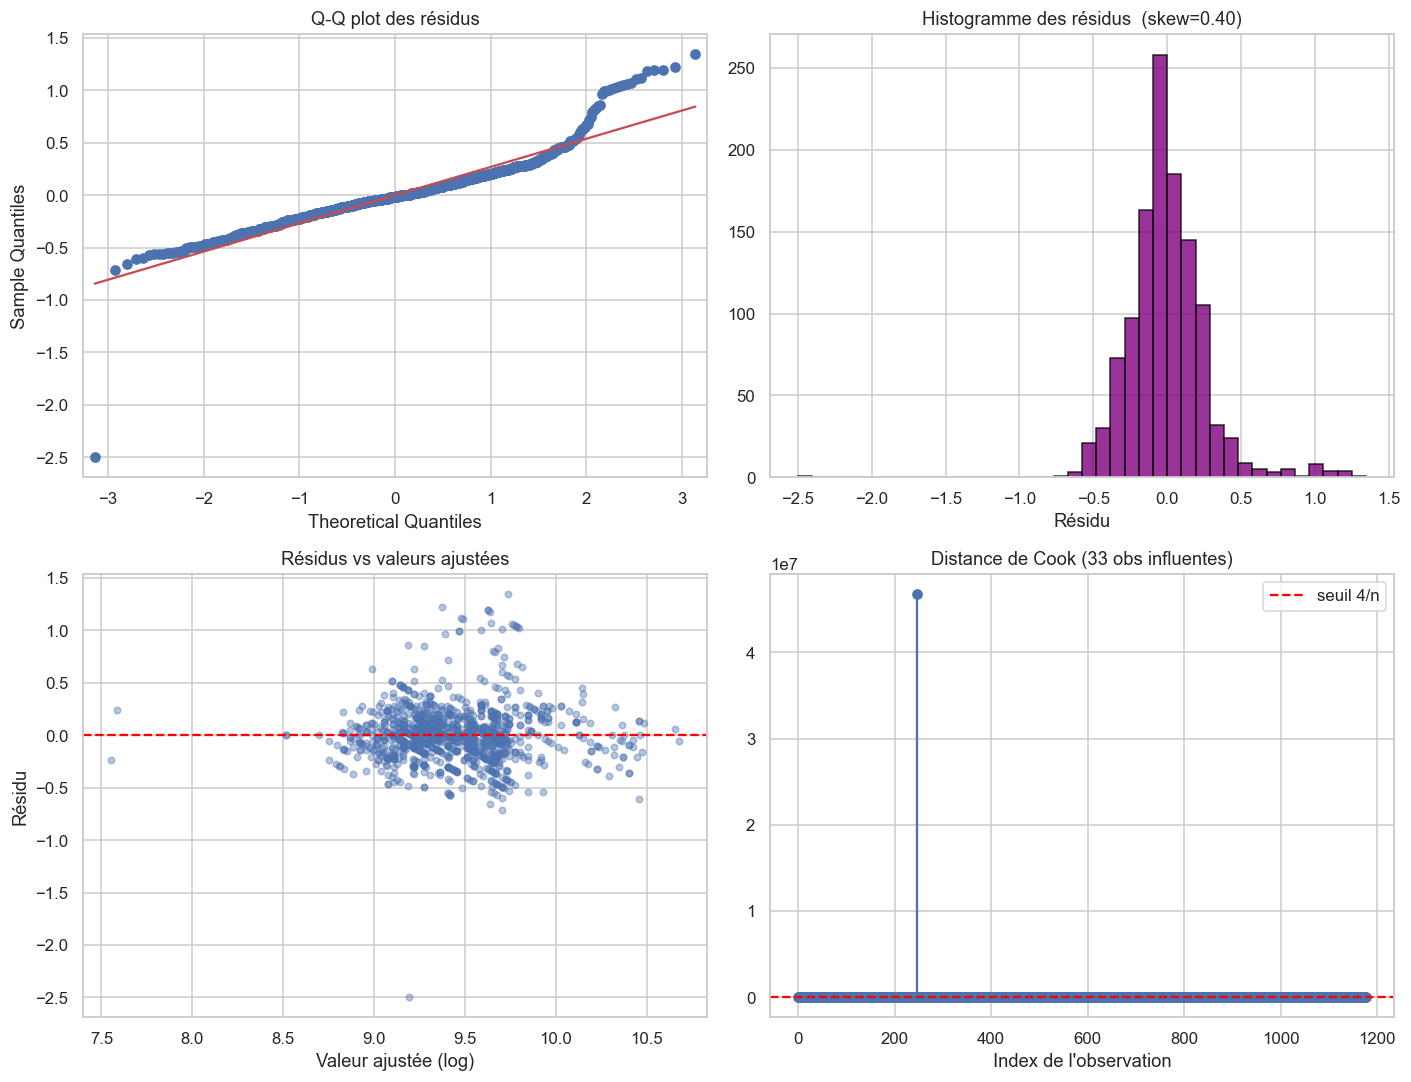

In [38]:
# Diagnostic visuel
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Q-Q plot
sm.qqplot(resid, line="s", ax=axes[0, 0])
axes[0, 0].set_title("Q-Q plot des résidus")

# (b) Histogramme des résidus
axes[0, 1].hist(resid, bins=40, color="purple", edgecolor="black", alpha=.8)
axes[0, 1].set_title(f"Histogramme des résidus  (skew={skw:.2f})")
axes[0, 1].set_xlabel("Résidu")

# (c) Résidus vs fitted (homoscédasticité)
axes[1, 0].scatter(fitted, resid, alpha=.4, s=18)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("Résidus vs valeurs ajustées")
axes[1, 0].set_xlabel("Valeur ajustée (log)")
axes[1, 0].set_ylabel("Résidu")

# (d) Distance de Cook
infl = OLSInfluence(ols_final)
cook = infl.cooks_distance[0]
axes[1, 1].stem(range(len(cook)), cook, basefmt=" ")
axes[1, 1].axhline(4/len(cook), color="red", linestyle="--", label="seuil 4/n")
axes[1, 1].set_title(f"Distance de Cook ({(cook > 4/len(cook)).sum()} obs influentes)")
axes[1, 1].set_xlabel("Index de l'observation")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [39]:
# Ré-estimation avec erreurs robustes HC3 si hétéroscédasticité confirmée
ols_robust = sm.OLS(y_train, X_train_final_sm).fit(cov_type="HC3")
print("Modèle final avec écarts-types robustes HC3 :")
print(f"  R² = {ols_robust.rsquared:.4f}  |  R² adj = {ols_robust.rsquared_adj:.4f}")
print(f"  F = {ols_robust.fvalue:.2f}      |  p(F) = {ols_robust.f_pvalue:.2e}")

Modèle final avec écarts-types robustes HC3 :
  R² = 0.5932  |  R² adj = 0.5763
  F = 46.33      |  p(F) = 1.44e-210


c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 48, but rank is 41
  warnings.warn('covariance of constraints does not have full '


## 11. Validation hors échantillon

In [48]:
def metrics_block(y_true_log, y_pred_log, label):
    y_true = np.exp(y_true_log); y_pred = np.exp(y_pred_log)
    return {
        "Set":   label,
        "RMSE":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":   mean_absolute_error(y_true, y_pred),
        "MAPE":  np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R²":    r2_score(y_true, y_pred)
    }

train_m = metrics_block(y_train, ols_final.predict(X_train_final_sm), "TRAIN")
test_m  = metrics_block(y_test,  ols_final.predict(X_test_final_sm),  "TEST ")

# K-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=RNG)
cv_r2 = cross_val_score(LinearRegression(), X[final_vars], y_log, cv=kf, scoring="r2")

perf = pd.DataFrame([train_m, test_m]).round(4)
perf

,Set,RMSE,MAE,MAPE,R²
0,TRAIN,5110.4593,2753.9361,19.0085,0.4786
1,TEST,4883.0230,2722.3347,18.1746,0.4374


In [49]:
print(f"R² Cross-Val 5-fold : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"R² par fold        : {np.round(cv_r2, 4)}")

R² Cross-Val 5-fold : 0.5532 ± 0.0726
R² par fold        : [0.5706 0.622  0.5854 0.5753 0.4124]


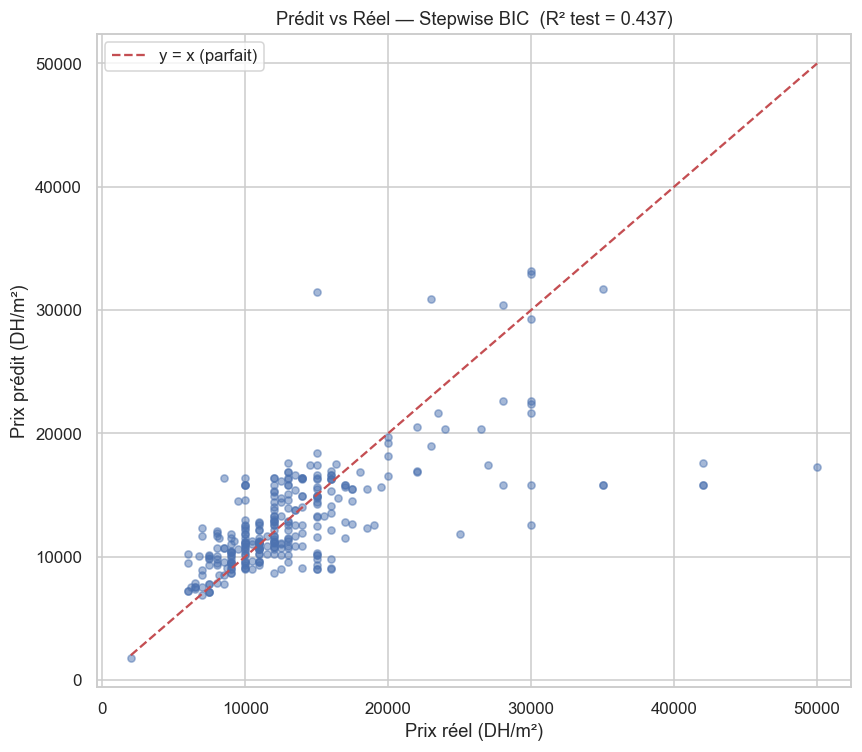

In [50]:
# Visualisation prédit vs réel (test)
y_pred_test = ols_final.predict(X_test_final_sm)
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(np.exp(y_test), np.exp(y_pred_test), alpha=.5, s=22)
mn, mx = np.exp(y_test).min(), np.exp(y_test).max()
ax.plot([mn, mx], [mn, mx], "r--", label="y = x (parfait)")
ax.set_xlabel("Prix réel (DH/m²)")
ax.set_ylabel("Prix prédit (DH/m²)")
ax.set_title(f"Prédit vs Réel — Stepwise BIC  (R² test = {test_m['R²']:.3f})")
ax.legend()
plt.tight_layout(); plt.show()